1. Setup và Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from windrose import WindroseAxes

# 0. Thiết lập chung
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# 1. Load Data
df = pd.read_csv('../data/processed/hcmc_merged_cleaned.csv')
df['datetime_local'] = pd.to_datetime(df['datetime_local'])
df.set_index('datetime_local', inplace=True)

# Danh sách các biến cần phân tích theo yêu cầu
all_features = [
    'pm25', 'pm1', 'temperature_2m', 'relative_humidity_2m', 
    'wind_speed_10m', 'wind_direction_10m', 'boundary_layer_height', 
    'surface_pressure', 'precipitation'
]

BƯỚC 1: UNIVARIATE CHO TẤT CẢ CÁC BIẾN (Looping)


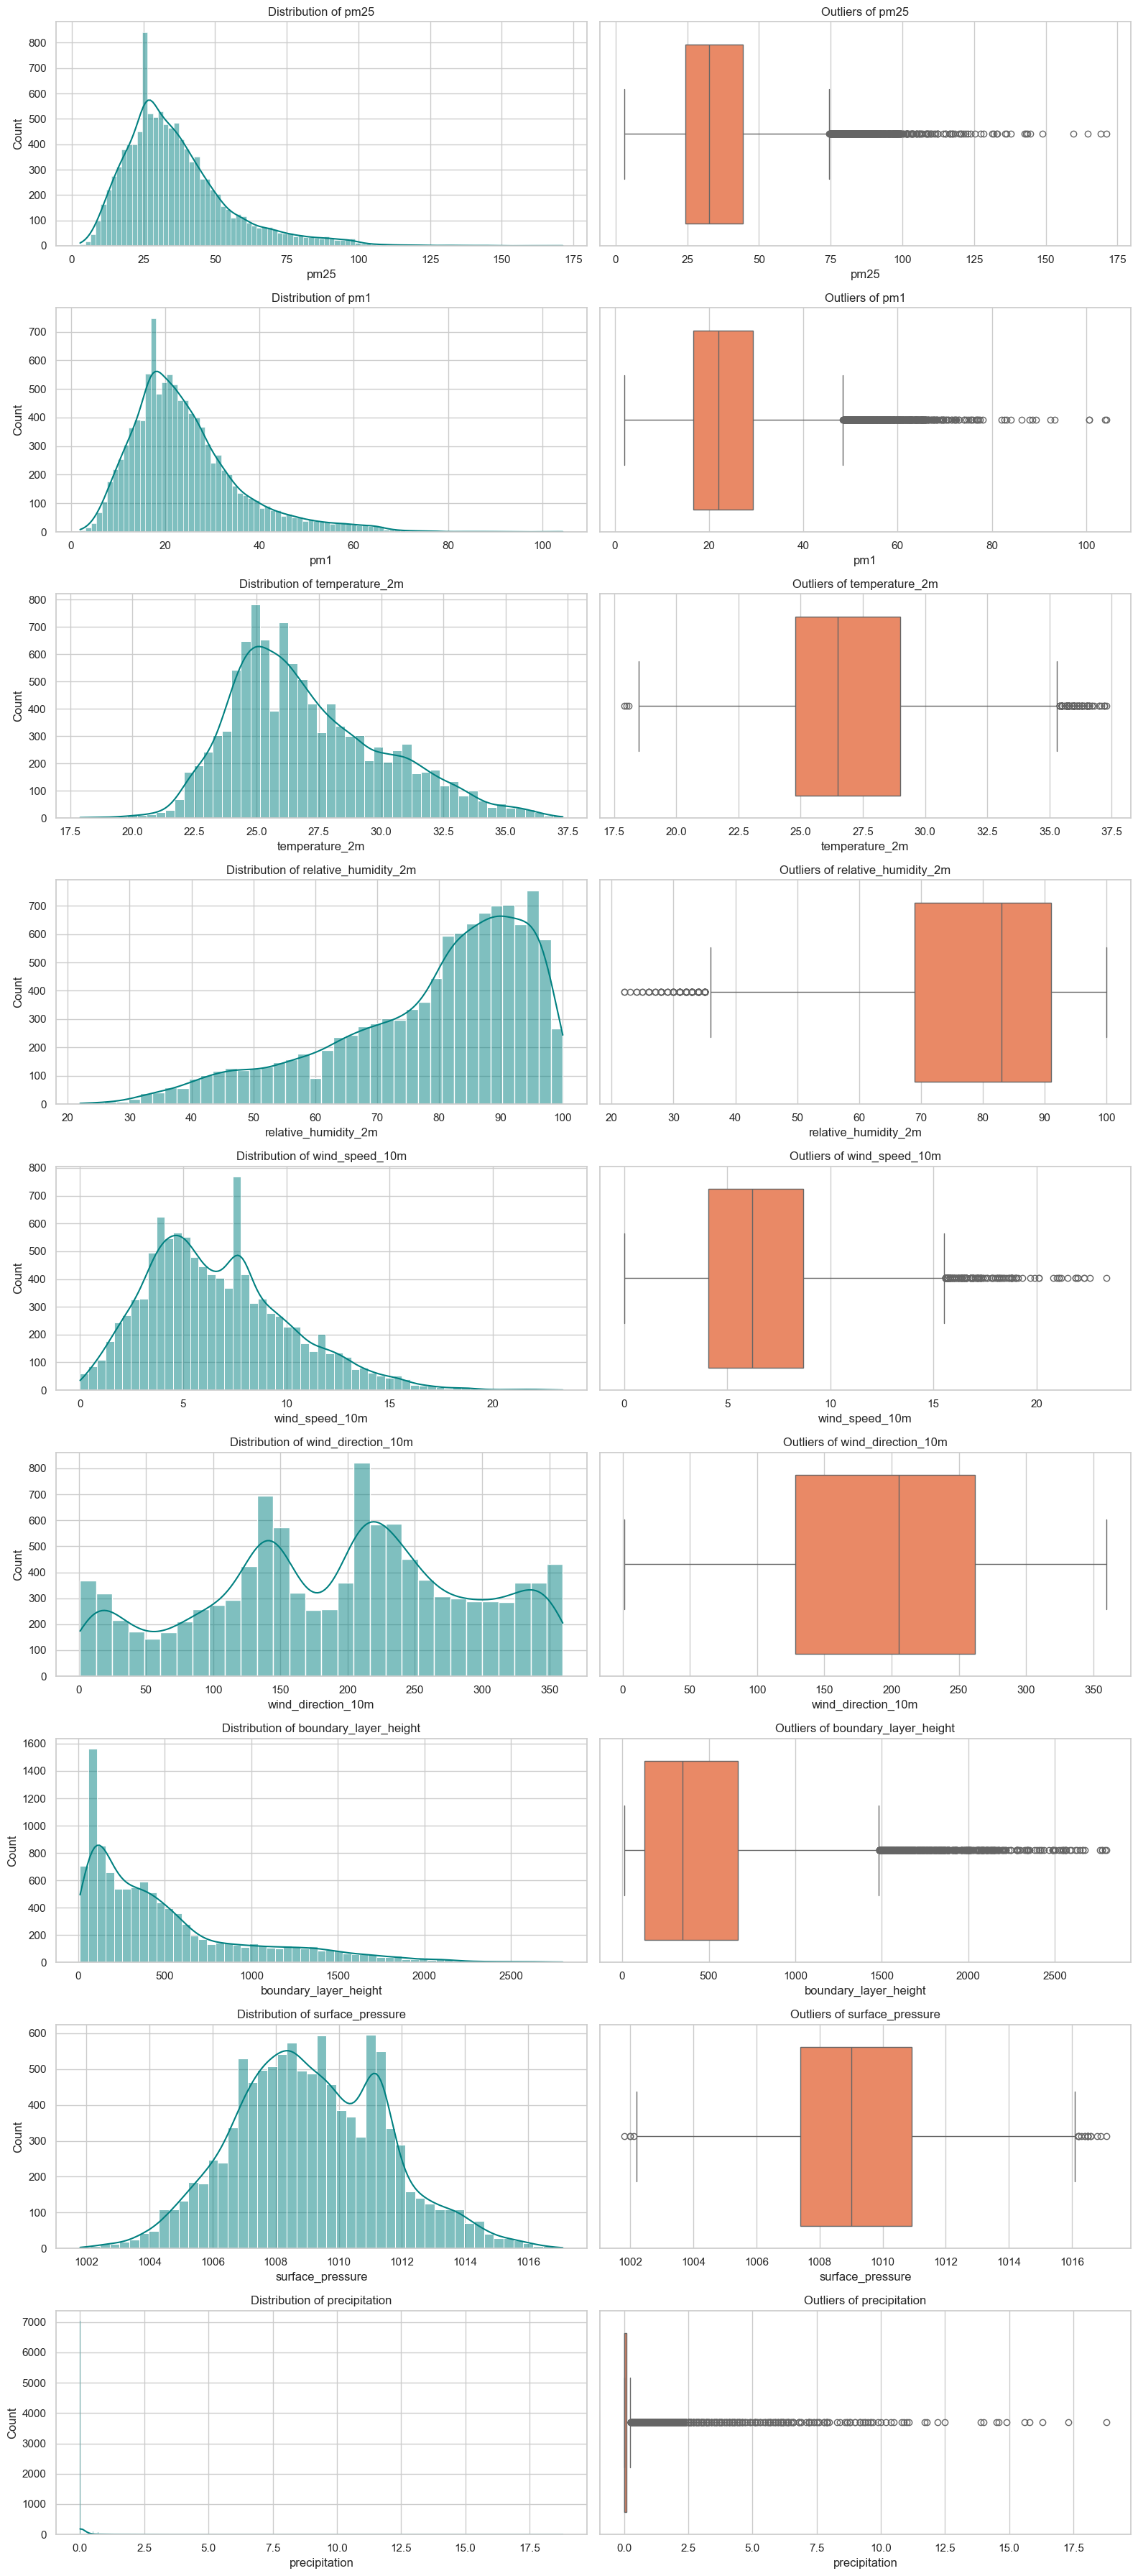

In [4]:
fig, axes = plt.subplots(len(all_features), 2, figsize=(16, 4 * len(all_features)))

for i, col in enumerate(all_features):
    # Histogram & KDE (Distribution)
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='teal')
    axes[i, 0].set_title(f'Distribution of {col}')
    
    # Boxplot (Outliers)
    sns.boxplot(x=df[col], ax=axes[i, 1], color='coral')
    axes[i, 1].set_title(f'Outliers of {col}')

plt.tight_layout()
plt.show()

BƯỚC 2: BIVARIATE VỚI REGRESSION LINES

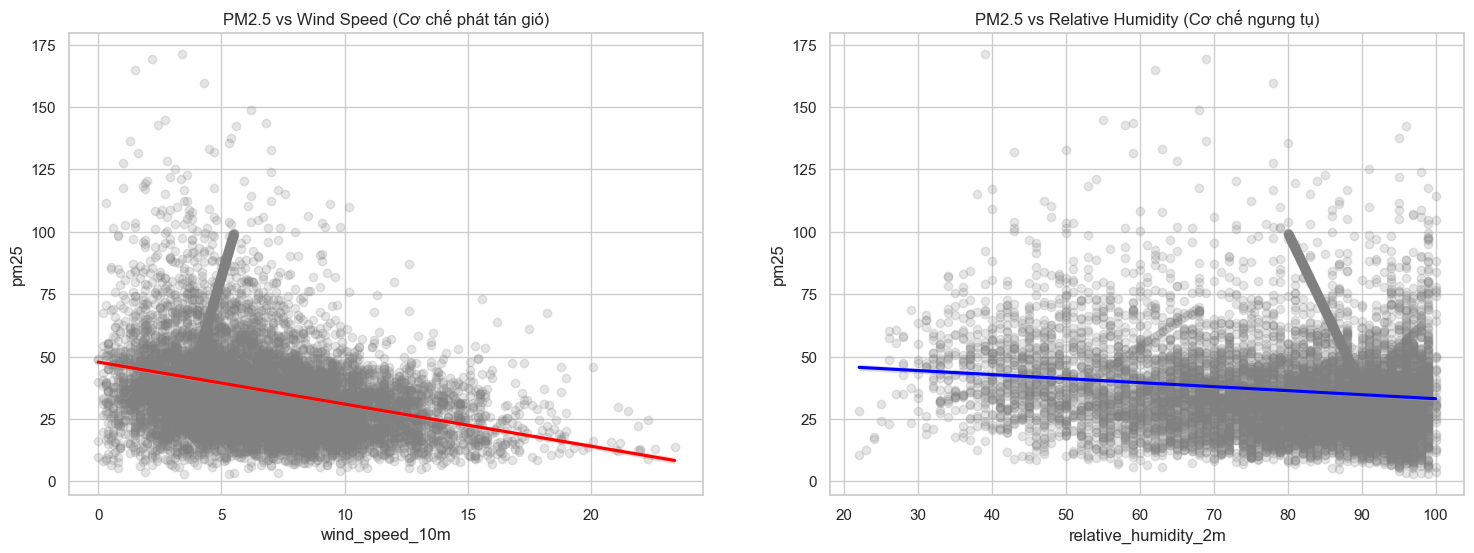

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# PM2.5 vs Wind Speed
sns.regplot(data=df, x='wind_speed_10m', y='pm25', ax=ax1, 
            scatter_kws={'alpha':0.2, 'color':'gray'}, line_kws={'color':'red'})
ax1.set_title('PM2.5 vs Wind Speed (Cơ chế phát tán gió)')

# PM2.5 vs Humidity
sns.regplot(data=df, x='relative_humidity_2m', y='pm25', ax=ax2, 
            scatter_kws={'alpha':0.2, 'color':'gray'}, line_kws={'color':'blue'})
ax2.set_title('PM2.5 vs Relative Humidity (Cơ chế ngưng tụ)')
plt.show()

BƯỚC 3: BINNING WIND DIRECTION & BOXPLOT

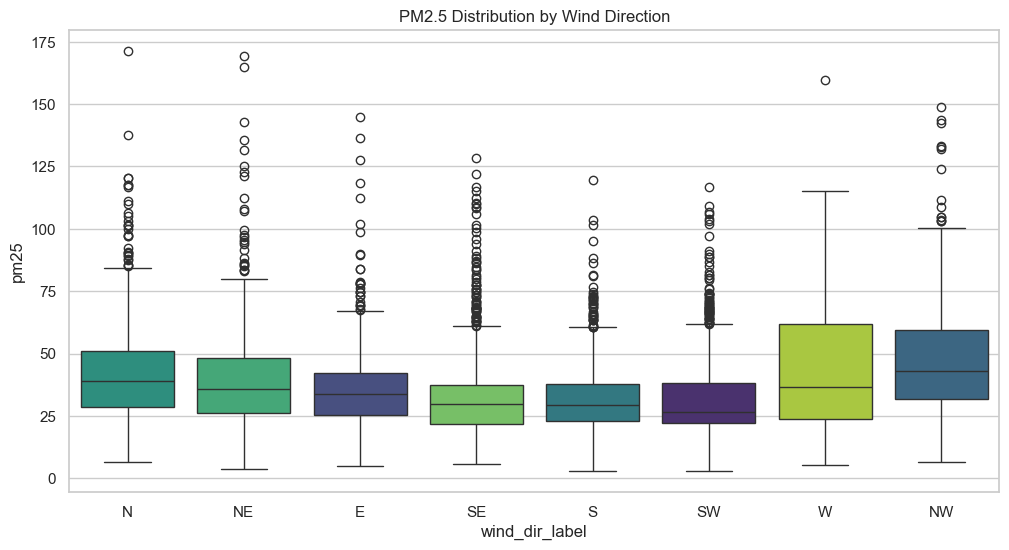

In [10]:
# Phân tích Hướng gió bằng Boxplot 

# Hàm chuyển độ (0-360) sang 8 hướng chính
def wind_dir_to_label(deg):
    labels = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
    return labels[int(((deg + 22.5) % 360) / 45)]

df['wind_dir_label'] = df['wind_direction_10m'].apply(wind_dir_to_label)
order = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df, 
    x='wind_dir_label', 
    y='pm25', 
    order=order, 
    palette='viridis',
    hue='wind_dir_label', 
    legend=False         
)
plt.title('PM2.5 Distribution by Wind Direction')
plt.show()

BƯỚC 4: MULTIVARIATE - POLLUTION ROSE 

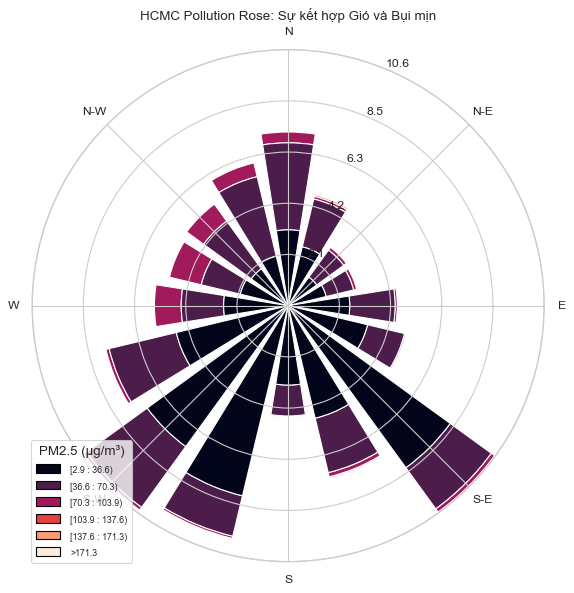

In [12]:
# Vẽ Pollution Rose (Wind Direction + Speed + PM2.5)
ax = WindroseAxes.from_ax()
ax.bar(df.wind_direction_10m, df.pm25, normed=True, opening=0.8, edgecolor='white')
ax.set_legend(title="PM2.5 (µg/m³)")
plt.title("HCMC Pollution Rose: Sự kết hợp Gió và Bụi mịn")
plt.show()

BƯỚC 5: Phân tích sự suy giảm Autocorrelation (Lag 48h)

<Figure size 1200x500 with 0 Axes>

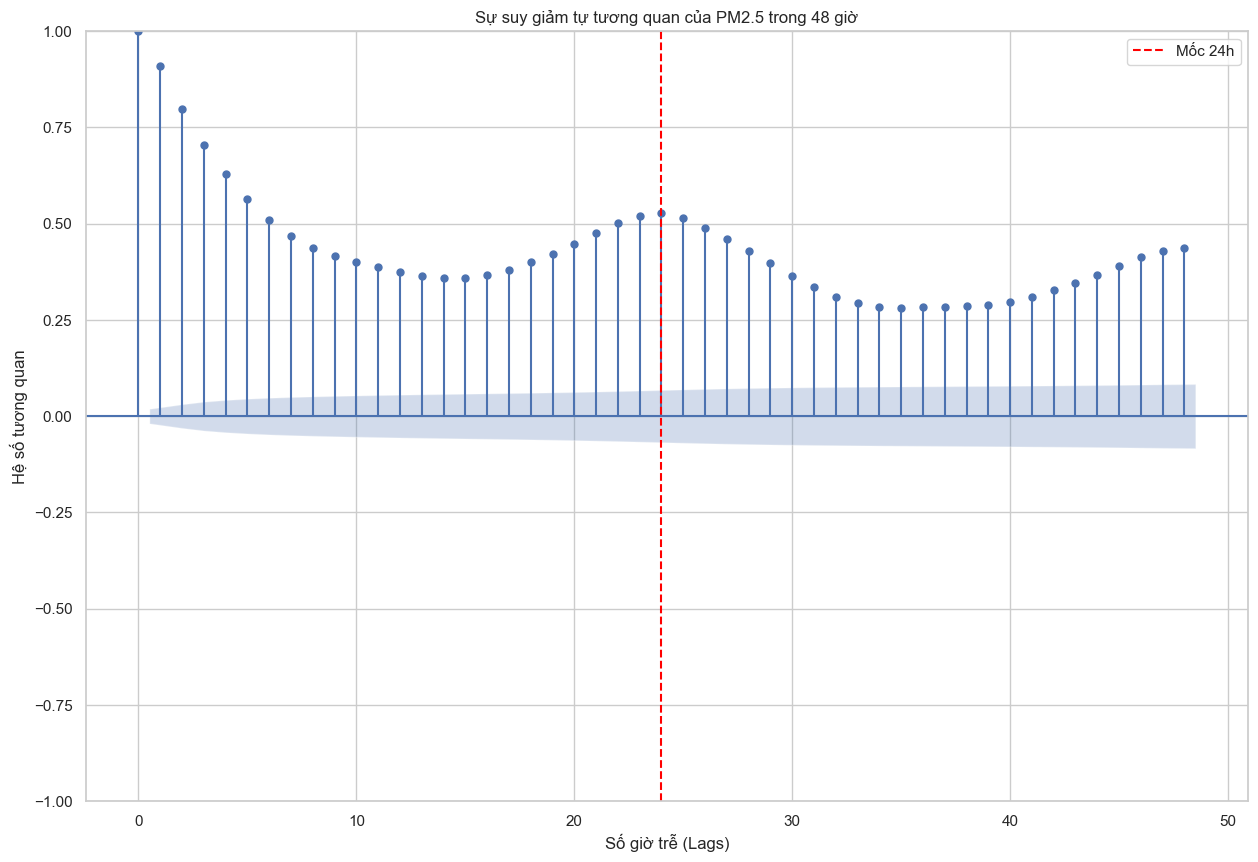

In [13]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 5))
# Lấy chuỗi PM2.5, loại bỏ giá trị NA và vẽ ACF trong 48 giờ
plot_acf(df['pm25'].dropna(), lags=48)
plt.title("Sự suy giảm tự tương quan của PM2.5 trong 48 giờ")
plt.xlabel("Số giờ trễ (Lags)")
plt.ylabel("Hệ số tương quan")
plt.axvline(x=24, color='red', linestyle='--', label='Mốc 24h')
plt.legend()
plt.show()

BƯỚC 6: KIỂM TRA SỰ TRÙNG LẶP

In [14]:
# Tính độ tương quan giữa 2 nguồn dữ liệu
temp_corr = df['temperature'].corr(df['temperature_2m'])
humid_corr = df['relativehumidity'].corr(df['relative_humidity_2m'])

print(f"Độ tương quan Nhiệt độ giữa 2 nguồn: {temp_corr:.4f}")
print(f"Độ tương quan Độ ẩm giữa 2 nguồn: {humid_corr:.4f}")

if temp_corr > 0.95:
    print("=> Insight: 2 nguồn nhiệt độ gần như trùng khớp, có thể bỏ bớt 1 cột khi huấn luyện mô hình.")

Độ tương quan Nhiệt độ giữa 2 nguồn: 0.7577
Độ tương quan Độ ẩm giữa 2 nguồn: 0.7781
